# Baseline: no_aerosols_zero_wind — 3D vs 1D

Diagnostics for the **no aerosols, zero wind** baseline experiment.

| Section | Content |
|---------|---------|
| **1. LWP** | 1D vs 3D timeseries and 3D − 1D difference + integral |
| **2. Surface energy balance** | Domain-mean SEB, residual, and cloud-conditioned fluxes |
| **3. Sub-cloud turbulent flux profiles** | Cloud-root vs cloud-free absolute H/LE profiles + decomposition |


In [1]:
import sys
import os
import pickle
import warnings
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path
from matplotlib.lines import Line2D

_HERE = Path.cwd()
sys.path.insert(0, str(_HERE))
sys.path.insert(0, str(_HERE / 'cloud_roots'))

from cass_analysis import (
    load_stats, load_stats_ensemble,
    RunSet,
    conditioned_means_ensemble,
    lwp_integral, _to_plottime,
    seb_residual,
    plot_seb_timeseries, plot_seb_residual, plot_flux_conditioned,
    sim_time_to_lst, lst_window_mask,
    FLUX_COLORS, RT_STYLE, RT_LABEL,
    rho, cp, Lv, LST_OFFSET,
)
from catalog import make_runset, CASS_ROOT

In [2]:
# ── experiment ────────────────────────────────────────────────────────────────
EXPT_KEY       = 'no_aerosols_zero_wind'
N_REPS         = 4
rs             = make_runset(EXPT_KEY, n_reps=N_REPS)
print(rs)

# ── cloud-root profile / composite config ─────────────────────────────────────
COMPOSITE_ROOT = str(CASS_ROOT / 'analysis' / 'cloud_root_composite')
LST_MIN        = 10.5
LST_MAX        = 17.5
ORIENT         = 'xz'
SAVE_PDF       = False

# ── CASES for cloud-root profiles / composites ────────────────────────────────
CASES = [
    dict(key='1D', rt='2stream',   comp_expt=EXPT_KEY, comp_rt='2stream'),
    dict(key='3D', rt='raytracer', comp_expt=EXPT_KEY, comp_rt='raytracer'),
]

RunSet('No aerosols, zero wind', root=/pscratch/sd/m/mpowell/CASS_LES/experiments/no_aerosols_zero_wind)
  2stream: 4 rep(s)
  raytracer: 4 rep(s)


In [3]:
# ── LWP loading ───────────────────────────────────────────────────────────────
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    dirs_2s = rs.dirs.get('2stream', [])
    dirs_rt = rs.dirs.get('raytracer', [])

reps_2s  = [load_stats(d) for d in dirs_2s]
reps_rt  = [load_stats(d) for d in dirs_rt]
n_paired = min(len(reps_2s), len(reps_rt))
nt       = min(*(s['qlqi_path'].sizes['time'] for s in reps_2s + reps_rt))

lwp_1d_reps = np.stack([s['qlqi_path'].values[:nt] * 1e3 for s in reps_2s[:n_paired]])
lwp_3d_reps = np.stack([s['qlqi_path'].values[:nt] * 1e3 for s in reps_rt[:n_paired]])
diff_reps   = lwp_3d_reps - lwp_1d_reps

lwp_1d     = lwp_1d_reps.mean(axis=0)
lwp_3d     = lwp_3d_reps.mean(axis=0)
lwp_1d_std = lwp_1d_reps.std(axis=0, ddof=0)
lwp_3d_std = lwp_3d_reps.std(axis=0, ddof=0)
diff       = diff_reps.mean(axis=0)
diff_std   = diff_reps.std(axis=0, ddof=0)

t_local = reps_2s[0]['t_local'].values[:nt]
t_sec   = reps_2s[0]['t_sec'].values[:nt]
dt_s    = float(t_sec[1] - t_sec[0]) if len(t_sec) > 1 else 60.0

cloudy_mask  = (lwp_1d > 0.1) | (lwp_3d > 0.1)
int_diff     = lwp_integral(diff, dt_s, cloudy_mask=cloudy_mask)
int_1d       = lwp_integral(lwp_1d, dt_s, cloudy_mask=cloudy_mask)
norm_int     = int_diff / int_1d * 100 if abs(int_1d) > 1e-6 else np.nan
norm_int_std = float(np.std(
    [lwp_integral(diff_reps[r], dt_s, cloudy_mask=cloudy_mask) / int_1d * 100
     for r in range(n_paired)], ddof=0)) if abs(int_1d) > 1e-6 else np.nan

print(f'LWP loaded:  n_paired={n_paired},  nt={nt}')
print(f'Normalised integral: {norm_int:+.2f} \u00b1 {norm_int_std:.2f} %')

LWP loaded:  n_paired=4,  nt=167
Normalised integral: +44.08 ± 1.63 %


## 1. LWP


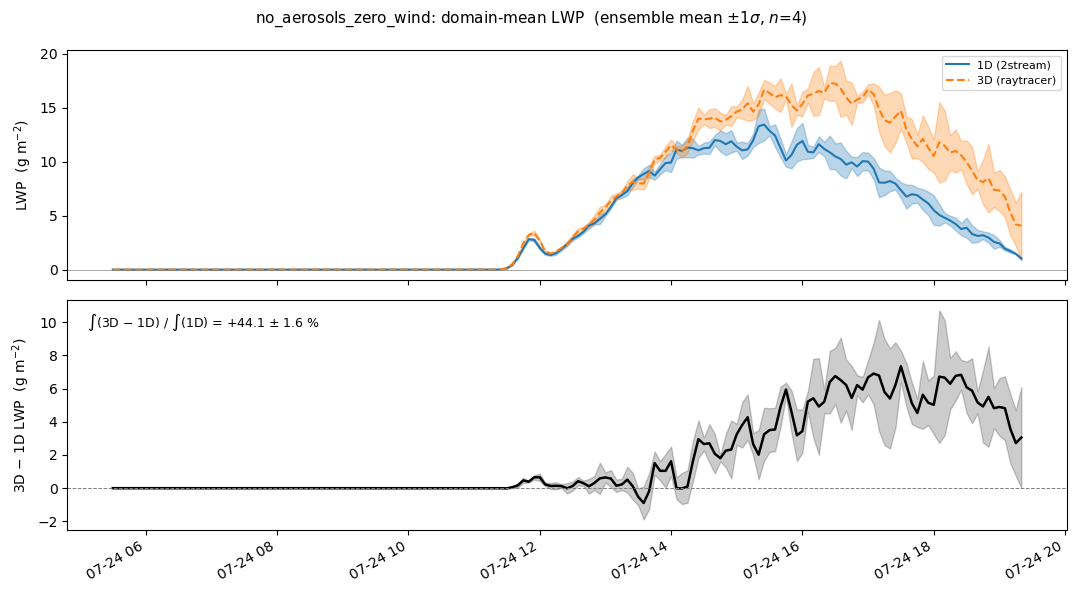

In [4]:
# ── Figure 1: LWP 1D vs 3D (top) + 3D − 1D difference (bottom) ───────────────
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
t_num = _to_plottime(t_local)

ax = axes[0]
ax.plot(t_num, lwp_1d, color='C0', lw=1.5, label='1D (2stream)')
ax.fill_between(t_num, lwp_1d - lwp_1d_std, lwp_1d + lwp_1d_std, color='C0', alpha=0.3)
ax.plot(t_num, lwp_3d, color='C1', lw=1.5, ls='--', label='3D (raytracer)')
ax.fill_between(t_num, lwp_3d - lwp_3d_std, lwp_3d + lwp_3d_std, color='C1', alpha=0.3)
ax.set_ylabel(r'LWP  (g m$^{-2}$)')
ax.axhline(0, color='gray', lw=0.5)
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(t_num, diff, color='k', lw=1.8)
ax.fill_between(t_num, diff - diff_std, diff + diff_std, color='k', alpha=0.2)
ax.axhline(0, color='gray', lw=0.7, ls='--')
ax.set_ylabel(r'3D $-$ 1D LWP  (g m$^{-2}$)')
ax.text(0.02, 0.95,
        fr'$\int$(3D $-$ 1D) / $\int$(1D) = {norm_int:+.1f} $\pm$ {norm_int_std:.1f} %',
        transform=ax.transAxes, fontsize=9, va='top')
ax.xaxis_date()
fig.autofmt_xdate()

fig.suptitle(
    fr'{EXPT_KEY}: domain-mean LWP  (ensemble mean $\pm1\sigma$, $n$={n_paired})',
    fontsize=11,
)
plt.tight_layout()
if SAVE_PDF:
    plt.savefig('lwp_baseline.pdf', bbox_inches='tight')
    print('Saved lwp_baseline.pdf')
plt.show()

## 2. Surface energy balance


In [5]:
# ── SEB: load ensemble stats ──────────────────────────────────────────────────
s2s_mean, s2s_std = load_stats_ensemble(rs.dirs['2stream'])
srt_mean, srt_std = load_stats_ensemble(rs.dirs['raytracer'])

print(f"2stream:   {len(rs.dirs['2stream'])} rep(s),  "
      f"t = {s2s_mean['t_local'].values[0]} → {s2s_mean['t_local'].values[-1]}")
print(f"raytracer: {len(rs.dirs['raytracer'])} rep(s),  "
      f"t = {srt_mean['t_local'].values[0]} → {srt_mean['t_local'].values[-1]}")

# ── SEB: load conditioned means (pickle cache) ────────────────────────────────
_SEB_CACHE = CASS_ROOT / 'analysis' / 'seb_cache'
_SEB_CACHE.mkdir(parents=True, exist_ok=True)

def _compute_cond(result):
    mean_d, std_d = result
    for d in (mean_d, std_d):
        for kind in d:
            d[kind] = {var: da.compute() for var, da in d[kind].items()}
    return mean_d, std_d

def _load_or_compute_conditioned(rep_dirs, cache_name, variables, force=False):
    cache_file = _SEB_CACHE / f'{cache_name}.pkl'
    if not force and cache_file.exists():
        with open(cache_file, 'rb') as fh:
            cached = pickle.load(fh)
        # Rebuild if cache predates 'domain' key
        if 'domain' in cached[0]:
            print(f'  [cache hit] {cache_file.name}')
            return cached
        print(f'  [stale cache — missing domain key] {cache_file.name}')
    print(f'  [computing] {cache_name} …')
    result = _compute_cond(conditioned_means_ensemble(rep_dirs, variables=variables))
    with open(cache_file, 'wb') as fh:
        pickle.dump(result, fh)
    print(f'  [cached]    {cache_file.name}')
    return result

_slug = f'experiments_{EXPT_KEY}'
cond_2s_mean, cond_2s_std = _load_or_compute_conditioned(
    rs.dirs['2stream'],
    f'{_slug}__2stream',
    variables=['thl_fluxbot', 'qt_fluxbot', 'sw_flux_dn'],
)
cond_rt_mean, cond_rt_std = _load_or_compute_conditioned(
    rs.dirs['raytracer'],
    f'{_slug}__raytracer',
    variables=['thl_fluxbot', 'qt_fluxbot', 'sw_flux_sfc_rt', 'sw_flux_dn'],
)
print('Done.')


2stream:   4 rep(s),  t = 2005-07-24T05:30:00.000000000 → 2005-07-24T19:19:59.999999999
raytracer: 4 rep(s),  t = 2005-07-24T05:30:00.000000000 → 2005-07-24T19:19:59.999999999
  [cache hit] experiments_no_aerosols_zero_wind__2stream.pkl
  [cache hit] experiments_no_aerosols_zero_wind__raytracer.pkl
Done.


2stream  peak|resid|=6.4  daytime_mean|resid|=0.2 W m⁻²
raytracer  peak|resid|=11.4  daytime_mean|resid|=3.7 W m⁻²


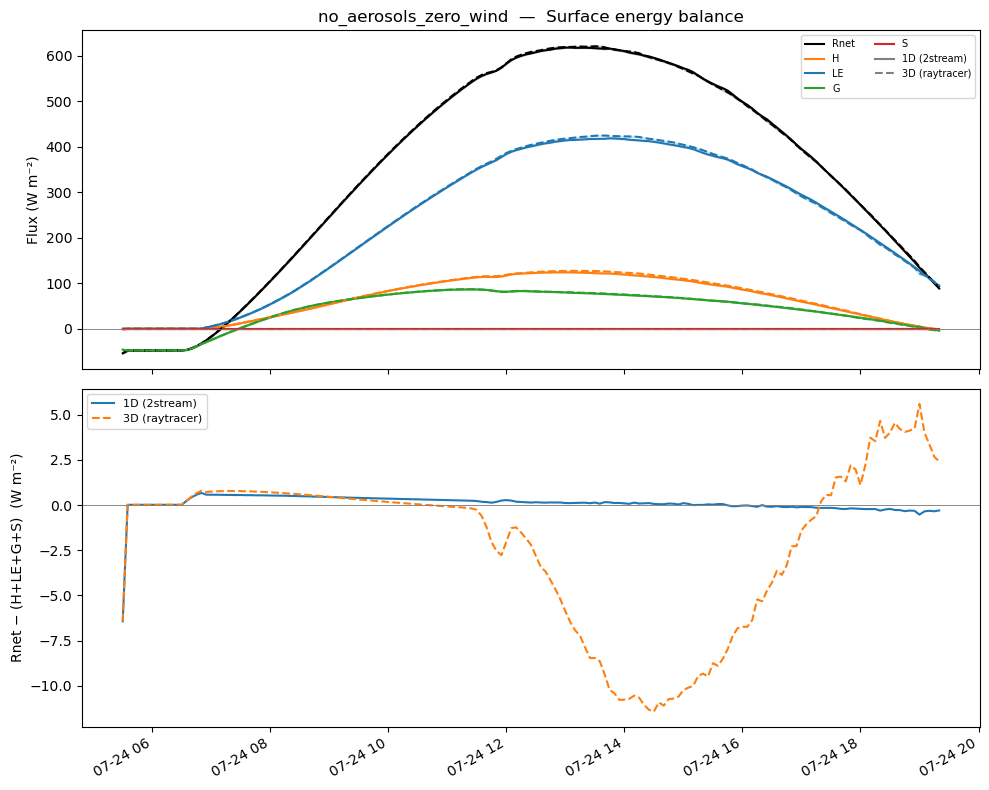

In [6]:
# ── Figure 2a: domain-mean SEB + residual ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax = axes[0]
for rt, sm, ss in [('2stream', s2s_mean, s2s_std), ('raytracer', srt_mean, srt_std)]:
    plot_seb_timeseries(ax, sm, ss, rt_type=rt)
flux_handles = [Line2D([0],[0], color=c, ls='-', label=f) for f, c in FLUX_COLORS.items()]
rt_handles   = [Line2D([0],[0], color='gray', ls=sty['ls'], label=RT_LABEL[rt])
                for rt, sty in RT_STYLE.items()]
ax.legend(handles=flux_handles + rt_handles, fontsize=7, ncol=2)
ax.set_title(f'{EXPT_KEY}  —  Surface energy balance')

ax = axes[1]
for rt, sm in [('2stream', s2s_mean), ('raytracer', srt_mean)]:
    plot_seb_residual(ax, sm, rt_type=rt)
for rt, sm in [('2stream', s2s_mean), ('raytracer', srt_mean)]:
    resid   = seb_residual(sm)
    daytime = sm['Rnet'] > 50
    print(f'{rt}  peak|resid|={np.abs(resid).max():.1f}  '
          f'daytime_mean|resid|={np.abs(resid[daytime]).mean():.1f} W m⁻²')
ax.legend(fontsize=8)

plt.tight_layout()
if SAVE_PDF:
    plt.savefig('seb_baseline.pdf', bbox_inches='tight')
    print('Saved seb_baseline.pdf')
plt.show()


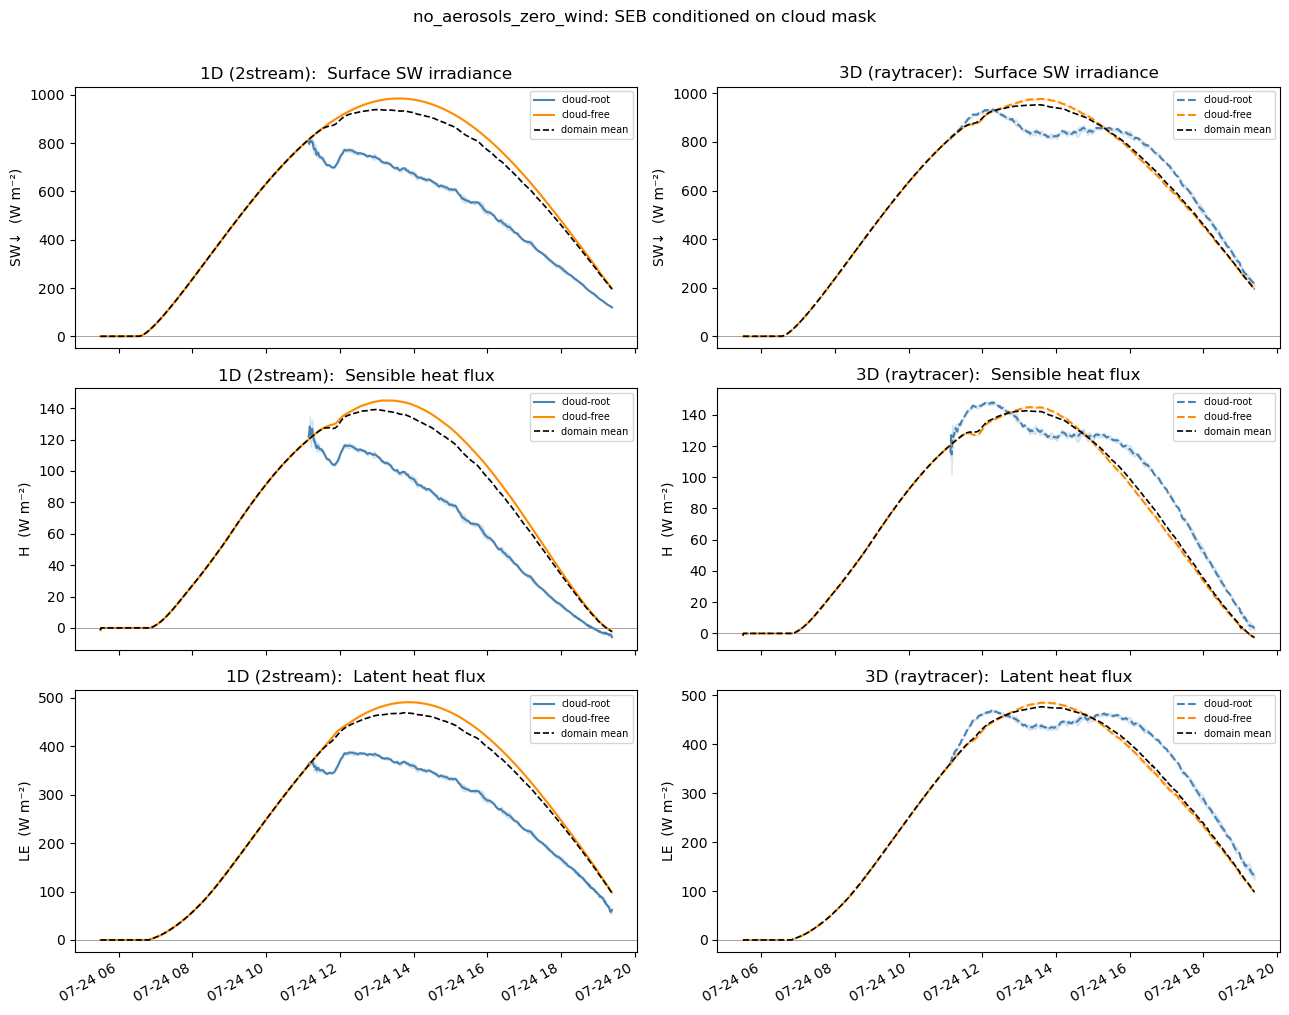

In [7]:
# ── Figure 2b: SEB conditioned on cloud mask ─────────────────────────────────
# Order: SW↓, H, LE.  Each panel includes domain mean from same xy fields.
fig, axes = plt.subplots(3, 2, figsize=(13, 10), sharex=True)

H_scale  = rho * cp
LE_scale = rho * Lv

for col, (rt, cm, cs) in enumerate([
    ('2stream',   cond_2s_mean, cond_2s_std),
    ('raytracer', cond_rt_mean, cond_rt_std),
]):
    t_local_c = cm['shaded']['thl_fluxbot'].time.values

    # Row 0: SW↓
    sw_key = 'sw_flux_sfc_rt' if 'sw_flux_sfc_rt' in cm['shaded'] else 'sw_flux_dn'
    plot_flux_conditioned(
        axes[0, col], t_local_c,
        cm['shaded'][sw_key], cm['unshaded'][sw_key],
        cs['shaded'].get(sw_key), cs['unshaded'].get(sw_key),
        rt_type=rt, ylabel='SW↓  (W m⁻²)', scale=1.0,
    )
    dm_sw = cm['domain'][sw_key]
    axes[0, col].plot(_to_plottime(dm_sw.time.values), dm_sw.values,
                      color='k', ls='--', lw=1.2, label='domain mean')
    axes[0, col].set_title(f'{RT_LABEL[rt]}:  Surface SW irradiance')

    # Row 1: H
    plot_flux_conditioned(
        axes[1, col], t_local_c,
        cm['shaded']['thl_fluxbot'], cm['unshaded']['thl_fluxbot'],
        cs['shaded'].get('thl_fluxbot'), cs['unshaded'].get('thl_fluxbot'),
        rt_type=rt, ylabel='H  (W m⁻²)', scale=H_scale,
    )
    dm_h = cm['domain']['thl_fluxbot']
    axes[1, col].plot(_to_plottime(dm_h.time.values), dm_h.values * H_scale,
                      color='k', ls='--', lw=1.2, label='domain mean')
    axes[1, col].set_title(f'{RT_LABEL[rt]}:  Sensible heat flux')

    # Row 2: LE
    plot_flux_conditioned(
        axes[2, col], t_local_c,
        cm['shaded']['qt_fluxbot'], cm['unshaded']['qt_fluxbot'],
        cs['shaded'].get('qt_fluxbot'), cs['unshaded'].get('qt_fluxbot'),
        rt_type=rt, ylabel='LE  (W m⁻²)', scale=LE_scale,
    )
    dm_le = cm['domain']['qt_fluxbot']
    axes[2, col].plot(_to_plottime(dm_le.time.values), dm_le.values * LE_scale,
                      color='k', ls='--', lw=1.2, label='domain mean')
    axes[2, col].set_title(f'{RT_LABEL[rt]}:  Latent heat flux')

for ax in axes.flat:
    ax.legend(fontsize=7)

plt.suptitle(f'{EXPT_KEY}: SEB conditioned on cloud mask', y=1.01)
plt.tight_layout()
if SAVE_PDF:
    plt.savefig('seb_conditioned_baseline.pdf', bbox_inches='tight')
    print('Saved seb_conditioned_baseline.pdf')
plt.show()


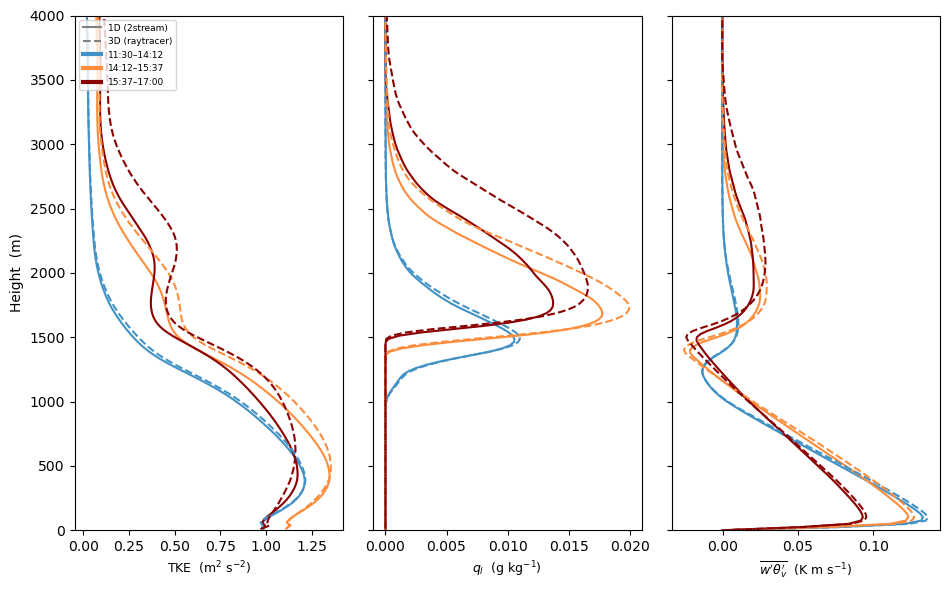

In [8]:
# ── Figure 2d: mean profiles by SZA window (1D vs 3D) ────────────────────────
# Mirrors the θ_z windows used for the circulation composites.
# Panels: θ_l, q_t, u, v, TKE (e), q_l, w'θ_v' (buoyancy flux)

import pandas as pd
s2s_mean, s2s_std = load_stats_ensemble(rs.dirs['2stream'])
srt_mean, srt_std = load_stats_ensemble(rs.dirs['raytracer'])

def _lst_hours(t_local):
    """Convert pandas DatetimeIndex / array to fractional LST hours."""
    t = pd.DatetimeIndex(t_local)
    return t.hour + t.minute / 60.0 + t.second / 3600.0

PROFILE_SPECS = [
    ('tke', 'z',  r'TKE  (m$^2$ s$^{-2}$)', 1.0),
    ('ql',  'z',  r'$q_l$  (g kg$^{-1}$)',  1e3),
    ('thv_w','zh', r"$\overline{w'\theta_v'}$  (K m s$^{-1}$)", 1.0),
]

from sw_surface_composite import WINDOWS as SZA_WINDOWS, WINDOW_LABELS as SZA_LABELS
n_win  = len(SZA_WINDOWS)
n_vars = len(PROFILE_SPECS)
Z_MAX  = 4000  # m — plot up to this height

fig, axes = plt.subplots(1, n_vars, figsize=(3.2 * n_vars, 6), sharey=True)

win_colors = ['#4292c6', '#fd8d3c', '#8B0000']  # same as SW composite windows
if n_win > len(win_colors):
    from matplotlib.cm import get_cmap
    win_colors = [get_cmap('viridis')(i / (n_win - 1)) for i in range(n_win)]

for rt, sm, ls_style, rt_lbl in [
    ('2stream',   s2s_mean, '-',  '1D'),
    ('raytracer', srt_mean, '--', '3D'),
]:
    lst_h = _lst_hours(sm['t_local'].values)
    for wi, (lst_lo, lst_hi) in enumerate(SZA_WINDOWS):
        mask = (lst_h >= lst_lo) & (lst_h <= lst_hi)
        if mask.sum() == 0:
            continue
        for col, (var, zgrid, xlabel, scale) in enumerate(PROFILE_SPECS):
            ax = axes[col]
            z  = sm[zgrid].values
            prof = sm[var].values[mask].mean(axis=0) * scale
            z_mask = z <= Z_MAX
            label = f'{rt_lbl} {SZA_LABELS[wi][:11]}' if col == 0 else None
            ax.plot(prof[z_mask], z[z_mask], color=win_colors[wi],
                    ls=ls_style, lw=1.5, label=label)
            ax.set_xlabel(xlabel, fontsize=9)

axes[0].set_ylabel('Height  (m)')
axes[0].set_ylim(0, Z_MAX)
# Build legend: line style = RT, colour = window
from matplotlib.lines import Line2D
rt_handles = [
    Line2D([0],[0], color='gray', ls='-',  lw=1.5, label='1D (2stream)'),
    Line2D([0],[0], color='gray', ls='--', lw=1.5, label='3D (raytracer)'),
]
win_handles = [
    Line2D([0],[0], color=win_colors[wi], ls='-', lw=3,
           label=SZA_LABELS[wi].split('(')[0].strip())
    for wi in range(n_win)
]
axes[0].legend(handles=rt_handles + win_handles, fontsize=6.5,
               loc='upper left', frameon=True)

plt.tight_layout()
if SAVE_PDF:
    plt.savefig('mean_profiles_windowed.pdf', bbox_inches='tight')
    print('Saved mean_profiles_windowed.pdf')
plt.show()


## 3. Sub-cloud turbulent flux profiles

Reads the cloud-root cache built by `cloud_roots/free_vs_nudge_cloud_roots.ipynb` (Section A).  
Run that notebook first if the cache does not exist.


In [9]:
# ── Derived constants ─────────────────────────────────────────────────────────
RHO_CP = rho * cp
RHO_LV = rho * Lv * 1e-3


def load_absolute_profiles(case, n_reps=N_REPS, lst_min=LST_MIN, lst_max=LST_MAX):
    """Load cached raw flux profiles and convert to H / LE in W m⁻².
    Cache must exist — run Section A of cloud_roots/free_vs_nudge_cloud_roots.ipynb first.
    """
    H_dom_reps, H_root_reps, H_free_reps   = [], [], []
    LE_dom_reps, LE_root_reps, LE_free_reps = [], [], []
    zeta = None

    for i in range(1, n_reps + 1):
        cache_path = (Path(COMPOSITE_ROOT) / case['comp_expt'] / case['comp_rt']
                      / f'rep_{i:02d}' / 'raw_flux_profile_cache.nc')
        if not cache_path.exists():
            print(f'  SKIP {case["key"]} rep_{i:02d}: cache not found')
            continue
        ds_c = xr.open_dataset(str(cache_path))
        if 'f_free_thl' not in ds_c or 't_hours' not in ds_c:
            ds_c.close()
            print(f'  SKIP {case["key"]} rep_{i:02d}: cache outdated')
            continue

        zeta   = ds_c['zeta'].values
        t_hrs  = ds_c['t_hours'].values
        mask_t = (t_hrs >= lst_min) & (t_hrs <= lst_max)

        if mask_t.sum() == 0:
            ds_c.close()
            continue

        H_dom_reps.append( np.nanmean(ds_c['f_domain_thl'].values[mask_t] * RHO_CP, axis=0))
        H_root_reps.append(np.nanmean(ds_c['f_cloud_thl'].values[mask_t]  * RHO_CP, axis=0))
        H_free_reps.append(np.nanmean(ds_c['f_free_thl'].values[mask_t]   * RHO_CP, axis=0))
        LE_dom_reps.append( np.nanmean(ds_c['f_domain_qv'].values[mask_t] * RHO_LV, axis=0))
        LE_root_reps.append(np.nanmean(ds_c['f_cloud_qv'].values[mask_t]  * RHO_LV, axis=0))
        LE_free_reps.append(np.nanmean(ds_c['f_free_qv'].values[mask_t]   * RHO_LV, axis=0))
        ds_c.close()

    def _s(lst): return np.stack(lst) if lst else np.empty((0,))
    return dict(zeta=zeta, n_reps=len(H_dom_reps),
                H_dom=_s(H_dom_reps),   H_root=_s(H_root_reps),  H_free=_s(H_free_reps),
                LE_dom=_s(LE_dom_reps), LE_root=_s(LE_root_reps), LE_free=_s(LE_free_reps))


def load_cloud_frac(case, n_reps=N_REPS, lst_min=LST_MIN, lst_max=LST_MAX):
    """Time-mean cloud-root area fraction per rep."""
    fracs = []
    for i in range(1, n_reps + 1):
        cache_path = (Path(COMPOSITE_ROOT) / case['comp_expt'] / case['comp_rt']
                      / f'rep_{i:02d}' / 'raw_flux_profile_cache.nc')
        if not cache_path.exists():
            continue
        ds_c = xr.open_dataset(str(cache_path))
        if 'cloud_frac' not in ds_c or 't_hours' not in ds_c:
            ds_c.close()
            continue
        t_hrs  = ds_c['t_hours'].values
        mask_t = (t_hrs >= lst_min) & (t_hrs <= lst_max)
        if mask_t.sum() > 0:
            fracs.append(float(np.nanmean(ds_c['cloud_frac'].values[mask_t])))
        ds_c.close()
    return np.array(fracs)


# ── Load ──────────────────────────────────────────────────────────────────────
abs_profiles = {}
for case in CASES:
    print(f"{RT_LABEL[case['rt']]} ... ", end="", flush=True)
    abs_profiles[case['key']] = load_absolute_profiles(case)
    print(f'{abs_profiles[case["key"]]["n_reps"]} reps')

cloud_fracs = {c['key']: load_cloud_frac(c) for c in CASES}
print('\nCloud-root area fraction  (mean ± 1σ)')
for key, fracs in cloud_fracs.items():
    if len(fracs) > 0:
        mu = fracs.mean()
        sd = fracs.std(ddof=1) if len(fracs) > 1 else 0.0
        print(f'  {key:6s}  α = {mu:.3f} ± {sd:.3f}  ({100*mu:.1f}%)')


1D (2stream) ... 4 reps
3D (raytracer) ... 4 reps

Cloud-root area fraction  (mean ± 1σ)
  1D      α = 0.112 ± 0.001  (11.2%)
  3D      α = 0.115 ± 0.001  (11.5%)


/tmp/ipykernel_1391378/609751186.py:34: RuntimeWarning: Mean of empty slice
  H_dom_reps.append( np.nanmean(ds_c['f_domain_thl'].values[mask_t] * RHO_CP, axis=0))
/tmp/ipykernel_1391378/609751186.py:35: RuntimeWarning: Mean of empty slice
  H_root_reps.append(np.nanmean(ds_c['f_cloud_thl'].values[mask_t]  * RHO_CP, axis=0))
/tmp/ipykernel_1391378/609751186.py:36: RuntimeWarning: Mean of empty slice
  H_free_reps.append(np.nanmean(ds_c['f_free_thl'].values[mask_t]   * RHO_CP, axis=0))
/tmp/ipykernel_1391378/609751186.py:37: RuntimeWarning: Mean of empty slice
  LE_dom_reps.append( np.nanmean(ds_c['f_domain_qv'].values[mask_t] * RHO_LV, axis=0))
/tmp/ipykernel_1391378/609751186.py:38: RuntimeWarning: Mean of empty slice
  LE_root_reps.append(np.nanmean(ds_c['f_cloud_qv'].values[mask_t]  * RHO_LV, axis=0))
/tmp/ipykernel_1391378/609751186.py:39: RuntimeWarning: Mean of empty slice
  LE_free_reps.append(np.nanmean(ds_c['f_free_qv'].values[mask_t]   * RHO_LV, axis=0))
/tmp/ipykernel_1391378

## 6. Convective velocity scale $w_*$

Verzijlbergh et al. (2009) domain-integrated convective velocity scale:

$$w_* = \left( c_1 \frac{g}{\theta_0} \int_0^{L_z} \overline{w'\theta_v'}\, dz \right)^{1/3}$$

with $c_1 = 2.5$.  Computed from domain-mean `thv_flux` stats profiles, averaged over **13:00–14:00 LST**.

In [11]:
# ── w_star: Verzijlbergh et al. (2009) convective velocity scale ──────────────
import netCDF4 as _nc4

C1         = 2.5
G          = 9.81
LST_WIN    = (13.0, 14.0)  # averaging window in LST hours


def compute_wstar(run_dir):
    """Compute w_* averaged over LST_WIN from stats thv_flux profile.

    Returns scalar w_* (m/s) or NaN if no valid times.
    """
    stats_path = sorted(Path(run_dir).glob('cass.default.*.nc'))
    if not stats_path:
        return np.nan
    ds = _nc4.Dataset(stats_path[0])

    t_sim  = np.asarray(ds.variables['time'][:])         # seconds
    zh     = np.asarray(ds.variables['zh'][:])            # half-levels (m)
    thvref = np.asarray(ds.groups['thermo'].variables['thvref'][:])  # (z,) full levels
    flux   = np.asarray(ds.groups['thermo'].variables['thv_flux'][:])  # (time, zh)
    ds.close()

    # time mask for LST window
    t_lst = t_sim / 3600.0 + LST_OFFSET
    mask  = (t_lst >= LST_WIN[0]) & (t_lst < LST_WIN[1])
    if not mask.any():
        return np.nan

    # mean flux profile over the window
    flux_mean = flux[mask].mean(axis=0)    # (zh,)

    # integrate flux over domain height using trapezoidal rule
    integral = np.trapz(flux_mean, zh)     # K m/s * m = K m^2/s

    # reference theta_0: use mean thvref
    theta_0 = float(thvref.mean())

    if integral <= 0:
        return np.nan

    wstar = (C1 * G / theta_0 * integral) ** (1.0 / 3.0)
    return float(wstar)


# ── compute for all reps × both RT types ──────────────────────────────────────
wstar_data = {}  # key → list of w_* values (one per rep)

for case in CASES:
    rt_key   = case['key']
    run_root = Path(rs.root) / case['rt']
    vals = []
    for i in range(1, N_REPS + 1):
        rep_dir = run_root / f'rep_{i:02d}'
        if not rep_dir.exists():
            print(f'  SKIP {rt_key} rep_{i:02d}')
            continue
        ws = compute_wstar(rep_dir)
        vals.append(ws)
        print(f'  {rt_key} rep_{i:02d}  w* = {ws:.3f} m/s')
    wstar_data[rt_key] = np.array(vals)
    print(f'{rt_key}: mean w* = {np.nanmean(vals):.3f} +/- {np.nanstd(vals):.3f} m/s')

/tmp/ipykernel_1391378/3937997334.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(flux_mean, zh)     # K m/s * m = K m^2/s


  1D rep_01  w* = 1.903 m/s
  1D rep_02  w* = 1.900 m/s
  1D rep_03  w* = 1.906 m/s
  1D rep_04  w* = 1.900 m/s
1D: mean w* = 1.902 +/- 0.003 m/s
  3D rep_01  w* = 1.937 m/s
  3D rep_02  w* = 1.938 m/s
  3D rep_03  w* = 1.939 m/s
  3D rep_04  w* = 1.936 m/s
3D: mean w* = 1.937 +/- 0.001 m/s


## 7. LWP integral time scale  $T_\tau$

Domain-mean sliding-window integral time scale of LWP (Taylor 1921, Stull 1988):

$$T_\tau(t) = \Delta t \sum_{\ell=0}^{\ell_0 - 1} \rho_\ell$$

where $\ell_0$ is the first lag where $\rho \leq 0$, estimated over a symmetric 2-hour window centred on $t$.

Cache built by `analysis/t_scale/compute_T_scale.py` (submit via `submit_T_scale.sh`).

2stream: 4 rep(s) loaded
raytracer: 4 rep(s) loaded


/tmp/ipykernel_1391378/964803901.py:37: RuntimeWarning: Mean of empty slice
  mu    = np.nanmean(stack, axis=0) / 60.0              # seconds → minutes
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


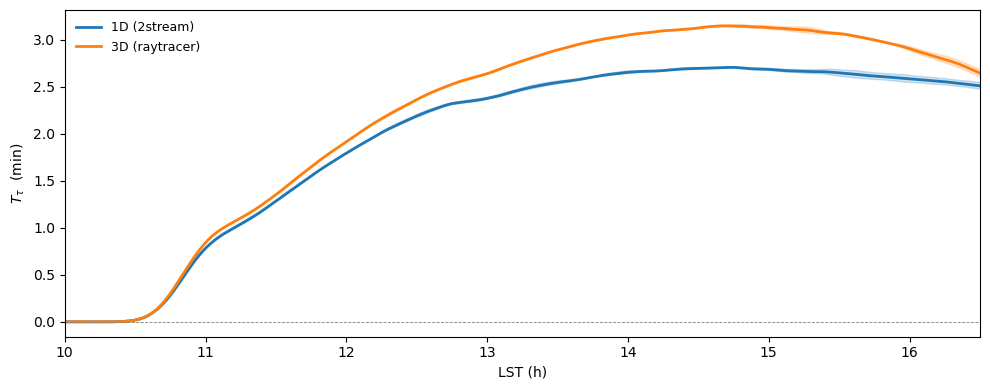

In [13]:
# ── Load T_scale cache ────────────────────────────────────────────────────────
_TS_ROOT = CASS_ROOT / 'analysis' / 'timescale' / EXPT_KEY

_RT_CFG = [
    ('2stream',   RT_STYLE['2stream']['color'], RT_LABEL['2stream']),
    ('raytracer', RT_STYLE['raytracer']['color'], RT_LABEL['raytracer']),
]

ts_data = {}
for rt, color, label in _RT_CFG:
    reps = []
    for i in range(1, N_REPS + 1):
        nc = _TS_ROOT / rt / f'rep_{i:02d}' / 'T_scale.nc'
        if not nc.exists():
            print(f'  MISSING: {nc}')
            continue
        ds_ts = xr.open_dataset(nc)
        reps.append({
            't_lst_h':      ds_ts.t_lst_h.values,
            'T_scale_mean': ds_ts.T_scale_mean.values,
        })
        ds_ts.close()
    ts_data[rt] = reps
    print(f'{rt}: {len(reps)} rep(s) loaded')

# ── Figure 7: domain-mean T_τ — 1D vs 3D ─────────────────────────────────────
LST_PLOT_MIN, LST_PLOT_MAX = 10.0, 16.5   # adjust as needed

fig, ax = plt.subplots(figsize=(10, 4))

for rt, color, label in _RT_CFG:
    reps = ts_data.get(rt, [])
    if not reps:
        continue
    t_h   = reps[0]['t_lst_h']
    stack = np.stack([r['T_scale_mean'] for r in reps])   # (n_reps, T)
    mu    = np.nanmean(stack, axis=0) / 60.0              # seconds → minutes
    sd    = np.nanstd(stack,  axis=0, ddof=0) / 60.0

    ax.plot(t_h, mu, color=color, lw=2.0, label=label)
    ax.fill_between(t_h, mu - sd, mu + sd, color=color, alpha=0.2)

ax.set_xlabel('LST (h)')
ax.set_ylabel(r'$T_\tau$  (min)')
ax.set_xlim(LST_PLOT_MIN, LST_PLOT_MAX)
ax.set_xticks(np.arange(LST_PLOT_MIN, LST_PLOT_MAX + 0.5, 1))
ax.axhline(0, color='gray', lw=0.6, ls='--')
ax.legend(fontsize=9, frameon=False)
# ax.set_title(
#     fr'{EXPT_KEY}: domain-mean LWP integral time scale'
#     r'  (window = 2 h,  nlags = 30 min,  ensemble mean $\pm1\sigma$)',
#     fontsize=10,
# )
plt.tight_layout()
if SAVE_PDF:
    plt.savefig(f'T_scale_{EXPT_KEY}.pdf', bbox_inches='tight')
    print(f'Saved T_scale_{EXPT_KEY}.pdf')
plt.show()